# Macro-regime detection — Recall, Precision & F1, regime states & a final HMM

This notebook is **self-contained**: it reads only the CSVs in `./data/` and the local
`regime_taa.py`, and writes every result to `./outputs/`. It does four things.

1. **The metrics table.** For five feature configurations it fits two clustering engines
   (a Gaussian mixture, **GMM**, and a Gaussian hidden Markov model, **HMM**) and scores
   each engine's *crisis* flag against NBER recessions with **Recall** (fraction of recession
   months flagged), **Precision** (fraction of crisis flags that coincide with a recession),
   and **F1** (their harmonic mean). Each row also reports the number of input **features**
   and the number of **principal components (PCs)** the engine actually sees.
2. **Regime-state paths.** For every config × engine it draws the month-by-month regime
   state with NBER recessions shaded.
3. **Diagnostics.** Cluster-stability (seed ARI), silhouette and BIC for every config × engine.
4. **A final model.** It selects the **HMM of `altdata_full/bn_meanrank`** — the most
   balanced Recall / Precision among alt-data configurations with the fewest features — and
   characterises it: per-state feature distributions, PC factor loadings (with intuitive
   labels), per-state PC distributions, intuitive state labels, the transition matrix, and a
   per-month state-probability CSV.

**Outputs written to `./outputs/`:** `regime_metrics_table.csv`, `fig_state_paths.png`,
`table_diagnostics.csv`, `final_feature_by_state.csv`, `final_pc_loadings.csv`,
`final_pc_by_state.csv`, `final_transition_matrix.csv`, `final_state_probabilities.csv`,
plus heatmap figures (`fig_feature_by_state_z.png`, `fig_pc_loadings.png`,
`fig_pc_by_state.png`, `fig_transition_matrix.png`).

## 1 · Setup — determinism

Two layers make the pipeline byte-reproducible: (1) pin BLAS threads **before** importing
numpy; (2) force full-SVD PCA. Every estimator uses `random_state` / `seed = 0`.

In [1]:
import os
for _v in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS',
           'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ[_v] = '1'
os.environ['PYTHONHASHSEED'] = '0'

import sys, pathlib, functools, warnings, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.special import logsumexp
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as _PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import f_classif
from sklearn.metrics import silhouette_score, adjusted_rand_score
from IPython.display import display
warnings.filterwarnings('ignore')

ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
DATA = ROOT / 'data'
OUT  = ROOT / 'outputs'; OUT.mkdir(exist_ok=True)

import regime_taa as rt
rt.PCA = functools.partial(_PCA, svd_solver='full')   # determinism layer 2/2
print('numpy', np.__version__, '| pandas', pd.__version__, '| regime_taa loaded')

numpy 2.4.4 | pandas 3.0.2 | regime_taa loaded


## 2 · Inputs

* `fredmd_current.csv` — the FRED-MD monthly macro panel (raw levels + transform codes).
* `nber_usrec.csv` — the NBER recession indicator (monthly 0/1), the target the metrics score against.
* `altdata_monthly.csv` / `altdata_tcodes.csv` — the alternative-data universe (rates,
  factor returns, commodity/credit series) with their FRED transform codes.

We also build **21 engineered macro features** (yield-curve & credit spreads, real rates,
labour-market and equity-trend signals, inflation, etc.) from the FRED-MD raw series.

In [2]:
print('=== [1/7] Loading inputs + engineered features ===', flush=True)
INIT_END = pd.Timestamp('2017-12-01')    # feature-selection cutoff (the screen only sees data <= here)
WIN_1976 = pd.Timestamp('1976-01-01')    # bundle start

data, tcodes = rt.load_fredmd(str(DATA / 'fredmd_current.csv'))
usrec = rt.load_usrec(str(DATA / 'nber_usrec.csv'))
alt_all = pd.read_csv(DATA / 'altdata_monthly.csv', index_col=0, parse_dates=True)
alt_tc  = pd.read_csv(DATA / 'altdata_tcodes.csv', index_col=0)['tcode'].to_dict()
ALTC = [c for c in alt_all.columns if not c.startswith('FRX_')]   # alt-data universe

# engineered macro features (21), each paired with its FRED-MD transform code
g = lambda c: data[c]; cpi_yoy = 100 * g('CPIAUCSL').pct_change(12)
u3 = g('UNRATE').rolling(3).mean(); ey = 100.0 / g('S&P PE ratio')
ENG = {'YC_10Y3M': (g('GS10') - g('TB3MS'), 1), 'YC_10Y1Y': (g('GS10') - g('GS1'), 1),
       'YC_5Y3M': (g('GS5') - g('TB3MS'), 1), 'YC_10Y_FF': (g('GS10') - g('FEDFUNDS'), 1),
       'CREDIT_BAA10Y': (g('BAA') - g('GS10'), 1), 'CREDIT_BAA_AAA': (g('BAA') - g('AAA'), 1),
       'CREDIT_AAA10Y': (g('AAA') - g('GS10'), 1), 'REAL_FF': (g('FEDFUNDS') - cpi_yoy, 1),
       'REAL_10Y': (g('GS10') - cpi_yoy, 1), 'SAHM': (u3 - u3.rolling(12).min(), 1),
       'UNRATE_12M_CHG': (g('UNRATE') - g('UNRATE').shift(12), 1),
       'SPX_MOM12': (100 * g('S&P 500').pct_change(12), 1),
       'SPX_TREND': (100 * (g('S&P 500') / g('S&P 500').rolling(12).mean() - 1), 1),
       'SPX_PE': (g('S&P PE ratio'), 1), 'SPX_DY': (g('S&P div yield'), 1),
       'ERP': (ey - (g('GS10') - cpi_yoy), 1), 'INFL_YoY': (cpi_yoy, 1),
       'OIL_MOM12': (100 * g('OILPRICEx').pct_change(12), 1),
       'M2_REAL_YoY': (100 * (g('M2SL') / g('CPIAUCSL')).pct_change(12), 1),
       'CREDIT_GROWTH': (100 * g('BUSLOANS').pct_change(12), 1), 'VIX': (g('VIXCLSx'), 4)}
ENG = {k: (s.dropna(), tc) for k, (s, tc) in ENG.items()}
print(f'FRED-MD {data.shape} | alt-data {len(ALTC)} cols | NBER through {usrec.index.max().date()}')

=== [1/7] Loading inputs + engineered features ===
FRED-MD (801, 126) | alt-data 131 cols | NBER through 2026-04-01


## 3 · Feature bundles

`build()` assembles a chosen mix of blocks (macro / engineered / alt-data), keeps series
with at least 50% coverage, applies the FRED-MD stationarity transforms, standardises, and
runs PCA to **95% cumulative variance**. We build four bundles:

| bundle | blocks | role |
|---|---|---|
| `fb_macro` | macro only | supplies the regime-label target used by the `bn_meanrank` selector |
| `fb_macroeng` | macro + engineered | config **macro+eng** |
| `fb_comb` | macro + engineered + alt-data | configs **comb_all/\*** |
| `fb_alt` | alt-data only | configs **altdata_full/\*** |

In [3]:
def build(macro, eng, alt, window=WIN_1976):
    idx = data.loc[window:].index; d = pd.DataFrame(index=idx); tc = pd.Series(dtype=float)
    if macro:
        for c in data.columns: d[c] = data.loc[window:, c]; tc[c] = tcodes.get(c, 1)
    if eng:
        for k, (s, t) in ENG.items(): d[k] = s.reindex(idx); tc[k] = t
    if alt:
        a = alt_all[ALTC].reindex(idx)
        for c in a.columns:
            if a[c].isna().mean() <= 0.50: d[c] = a[c]; tc[c] = alt_tc[c]
    return rt.prepare_features(d, tc, exclude='exchange', pca_var=0.95, drop_initial=2)

print('=== [2/7] Building feature bundles ===', flush=True)
fb_macro    = build(True,  False, False)   # macro-only (label target for selection)
fb_macroeng = build(True,  True,  False)   # macro + engineered
fb_comb     = build(True,  True,  True)    # macro + engineered + alt-data
fb_alt      = build(False, False, True)    # alt-data only
for nm, fb in [('macro', fb_macro), ('macro+eng', fb_macroeng), ('comb', fb_comb), ('alt', fb_alt)]:
    print(f'  {nm:10s}: {len(fb.transformed.columns):3d} feats -> {fb.scores.shape[1]:2d} PCs  '
          f'({fb.transformed.index[0].date()} -> {fb.transformed.index[-1].date()})')

=== [2/7] Building feature bundles ===
  macro     : 120 feats -> 58 PCs  (1976-03-01 -> 2025-09-01)
  macro+eng : 141 feats -> 62 PCs  (1976-03-01 -> 2025-09-01)
  comb      : 176 feats -> 76 PCs  (1976-03-01 -> 2025-09-01)
  alt       :  35 feats -> 19 PCs  (1976-03-01 -> 2025-09-01)


## 4 · Feature selection & engine machinery

**`bn_meanrank` selection (look-ahead-free).** Using only data up to `INIT_END` (2017-12):
1. a **Bai & Ng (2008)** screen sizes $K$ — the count of features whose point-biserial
   $t$-statistic against the NBER dummy exceeds $c_N=\sqrt{2\ln N}$;
2. a **3-seed RandomForest `mean_rank`** (Gini + permutation + F-stat) ordered against the
   macro bundle's regime labels picks **which** $K$ features.
The chosen features are then re-PCA'd to 95% variance (`subset_pca`).

**Engines.** A diagonal-covariance **GMM** (6 components) and a pure-NumPy diagonal-Gaussian
**HMM** (6 states; Baum-Welch EM + Viterbi decoding). For both, the **crisis state** is the
one that *owns the most Mahalanobis-extreme months* (`ownership_crisis`) — robust to the
HMM's tendency to place all tail months in a single state.

In [4]:
def regime_labels(scores_df, we):
    sc = scores_df.loc[:we]
    return pd.Series(rt.RegimeModel(r=5, random_state=0, outlier_method='quantile',
                                    outlier_frac=0.15).fit(sc.values).labels_, index=sc.index)

def rank_features(fb, ylab):
    Xdf = pd.DataFrame(fb.scaler.transform(fb.transformed.values),
                       index=fb.transformed.index, columns=fb.columns)
    common = Xdf.index.intersection(ylab.index); X = Xdf.loc[common].values; yv = ylab.loc[common].values
    cols = list(fb.columns); ranks = []
    for seed in range(3):
        rf = RandomForestClassifier(n_estimators=200, max_features='sqrt', min_samples_leaf=3,
                                    random_state=seed, n_jobs=1).fit(X, yv)
        gini = pd.Series(rf.feature_importances_, index=cols)
        perm = pd.Series(permutation_importance(rf, X, yv, n_repeats=3, random_state=seed,
                                                n_jobs=1).importances_mean, index=cols)
        Fst = pd.Series(np.nan_to_num(f_classif(X, yv)[0]), index=cols)
        ranks.append((gini.rank(ascending=False) + perm.rank(ascending=False)
                      + Fst.rank(ascending=False)) / 3)
    return pd.concat(ranks, axis=1).mean(axis=1).sort_values()

def screen_tstats(fb, we):
    out = {}
    for col in fb.columns:
        feat = fb.transformed[col].dropna().loc[:we]; idx = feat.index.intersection(usrec.index)
        if len(idx) < 10: out[col] = 0.0; continue
        x = feat.loc[idx].values.astype(float); y = (usrec.loc[idx] > 0).astype(float).values
        if x.std() == 0 or y.std() == 0: out[col] = 0.0; continue
        r = np.corrcoef(x, y)[0, 1]; n = len(idx)
        out[col] = np.inf if abs(r) >= 1 else float(abs(r) * np.sqrt((n - 2) / (1 - r ** 2)))
    return pd.Series(out).sort_values(ascending=False)

def bn_select(fb, label_fb):
    # Bai & Ng screen sizes K; mean_rank orders which K. Selection sees only data <= INIT_END.
    ts = screen_tstats(fb, INIT_END); N = len(fb.columns)
    K = int((ts > np.sqrt(2 * np.log(N))).sum())
    order = rank_features(fb, regime_labels(label_fb.scores, INIT_END)).index
    return [c for c in order if c in fb.transformed.columns][:K]

def subset_pca(fb, cols):
    # full-sample PCA (95% var) on a feature subset; returns scores, feature list, fitted PCA
    avail = [c for c in cols if c in fb.transformed.columns]
    z = StandardScaler().fit_transform(fb.transformed[avail].values)
    cum = _PCA(svd_solver='full').fit(z).explained_variance_ratio_.cumsum()
    n = int((cum < 0.95).sum() + 1)
    pca = _PCA(n_components=n, svd_solver='full').fit(z)
    sc = pd.DataFrame(pca.transform(z), index=fb.transformed.index,
                      columns=[f'PC{i+1}' for i in range(n)])
    return sc, avail, pca

def scores_for(fb, sel, label_fb=None):
    # sel='all' -> the bundle's own PCA scores; sel='bn_meanrank' -> subset PCA on selection
    if sel == 'all':
        return fb.scores, list(fb.transformed.columns)
    cols = bn_select(fb, label_fb)
    sc, avail, _ = subset_pca(fb, cols)
    return sc, avail
print('selection helpers ready')

selection helpers ready


In [5]:
# ── pure-NumPy diagonal-Gaussian HMM ───────────────────────────────────────────
def _le(X, m, lv):
    T, d = X.shape; K = m.shape[0]; o = np.zeros((T, K))
    for k in range(K):
        df = X - m[k]
        o[:, k] = -0.5 * (np.sum(df**2 * np.exp(-lv[k]), 1) + np.sum(lv[k]) + d*np.log(2*np.pi))
    return o
def _fw(lb, lA, lp):
    T, K = lb.shape; la = np.zeros((T, K)); la[0] = lp + lb[0]
    for t in range(1, T): la[t] = logsumexp(la[t-1, :, None] + lA, 0) + lb[t]
    return la
def _bw(lb, lA):
    T, K = lb.shape; b = np.zeros((T, K))
    for t in range(T-2, -1, -1): b[t] = logsumexp(lA + lb[t+1] + b[t+1], 1)
    return b
def fit_hmm(X, n_states=6, n_iter=20, n_init=1, reg=1e-2, seed=0):
    T, d = X.shape; K = n_states; rng = np.random.default_rng(seed); bll, best = -np.inf, None
    for tr in range(n_init):
        km = KMeans(K, n_init=3, random_state=int(rng.integers(9999))).fit(X)
        m = km.cluster_centers_.copy(); lv = np.log(np.full((K, d), X.var(0).clip(1e-6)) + reg)
        A = np.full((K, K), 0.05 / (K-1)); np.fill_diagonal(A, 0.95); pi = np.ones(K) / K
        lp = -np.inf
        for _ in range(n_iter):
            lb = _le(X, m, lv); lA = np.log(A + 1e-300); lpi = np.log(pi + 1e-300)
            la = _fw(lb, lA, lpi); bw = _bw(lb, lA); ll = float(logsumexp(la[-1]))
            lg = la + bw; lg -= logsumexp(lg, 1, keepdims=True); gg = np.exp(lg); xi = np.zeros((K, K))
            for t in range(T-1):
                lx = la[t, :, None] + lA + lb[t+1] + bw[t+1]; xi += np.exp(lx - logsumexp(lx))
            gs = gg.sum(0).clip(1e-10); pi = gg[0] / gg[0].sum()
            A = xi / xi.sum(1, keepdims=True).clip(1e-10)
            m = (gg[:, :, None] * X[:, None, :]).sum(0) / gs[:, None]
            for k in range(K):
                df = X - m[k]; v = (gg[:, k, None] * df**2).sum(0) / gs[k] + reg; lv[k] = np.log(v)
            if abs(ll - lp) < 1e-3: break
            lp = ll
        if ll > bll: bll = ll; best = (m.copy(), lv.copy(), A.copy(), pi.copy())
    return (*best, bll)
def filt(X, m, lv, A, pi):
    # filtered (forward) posterior P(state_t | data up to t)
    la = _fw(_le(X, m, lv), np.log(A + 1e-300), np.log(pi + 1e-300))
    la -= logsumexp(la, 1, keepdims=True); return np.exp(la)
def vit(X, m, lv, A, pi):
    # Viterbi MAP state path
    T, K = len(X), m.shape[0]; lb = _le(X, m, lv); lA = np.log(A + 1e-300)
    ld = np.zeros((T, K)); ps = np.zeros((T, K), int); ld[0] = np.log(pi + 1e-300) + lb[0]
    for t in range(1, T): sc = ld[t-1, :, None] + lA; ps[t] = sc.argmax(0); ld[t] = sc.max(0) + lb[t]
    s = np.zeros(T, int); s[-1] = ld[-1].argmax()
    for t in range(T-2, -1, -1): s[t] = ps[t+1, s[t+1]]
    return s

def ownership_crisis(labels_tr, Xtr, frac=0.15):
    mu = Xtr.mean(0); VI = np.linalg.pinv(np.cov(Xtr.T) + 1e-6 * np.eye(Xtr.shape[1])); df = Xtr - mu
    dd = np.einsum('ij,jk,ik->i', df, VI, df); ext = dd >= np.quantile(dd, 1 - frac)
    K = int(labels_tr.max()) + 1
    return int(np.argmax([int(ext[labels_tr == k].sum()) for k in range(K)]))

def recall(flag, idx):
    # fraction of NBER recession months the model flags as crisis  (TP / (TP + FN))
    s = pd.Series(flag, index=idx); ix = s.index.intersection(usrec.index)
    c = s.loc[ix].astype(int).values; n = (usrec.loc[ix] > 0).astype(int).values
    tp = int(((c == 1) & (n == 1)).sum())
    fn = int(((c == 0) & (n == 1)).sum())
    return round(tp / (tp + fn), 3) if (tp + fn) > 0 else 0.0

def precision(flag, idx):
    # fraction of model crisis flags that coincide with NBER recessions  (TP / (TP + FP))
    s = pd.Series(flag, index=idx); ix = s.index.intersection(usrec.index)
    c = s.loc[ix].astype(int).values; n = (usrec.loc[ix] > 0).astype(int).values
    tp = int(((c == 1) & (n == 1)).sum())
    fp = int(((c == 1) & (n == 0)).sum())
    return round(tp / (tp + fp), 3) if (tp + fp) > 0 else 0.0

def f1_score(flag, idx):
    # harmonic mean of Recall and Precision
    r = recall(flag, idx); p = precision(flag, idx)
    return round(2 * r * p / (r + p), 3) if (r + p) > 0 else 0.0

def fit_engine(sc, engine):
    # fit GMM or HMM (6 states) once; return (states Series, crisis-state id, fit object/params)
    X = sc.values
    if engine == 'GMM':
        gm = GaussianMixture(6, covariance_type='diag', n_init=10, random_state=0,
                             reg_covar=1e-6, max_iter=100).fit(X)
        states = gm.predict(X); cs = ownership_crisis(states, X)
        return pd.Series(states, index=sc.index), int(cs), gm
    m, lv, A, pi, ll = fit_hmm(X, n_states=6, seed=0)
    if not np.isfinite(ll): m, lv, A, pi, ll = fit_hmm(X, n_states=6, seed=0)
    states = vit(X, m, lv, A, pi); cs = ownership_crisis(states, X)
    return pd.Series(states, index=sc.index), int(cs), (m, lv, A, pi, ll)
print('engine machinery ready')

engine machinery ready


In [6]:
# ── shared display helpers: feature descriptions + annotated heatmap ───────────
FEATURE_DESC = {
    'FF_RF':      'Risk-free rate — 1-month US T-bill (Fama-French)',
    'FF_Mkt_RF':  'Equity market excess return (Mkt-RF, Fama-French)',
    'FF_RMW':     'Profitability factor — Robust-minus-Weak (Fama-French)',
    'BAB_USA':    'Betting-Against-Beta factor (US)',
    'BLM_SPGSCI': 'S&P GSCI broad commodity index return',
    'IR_dtb3':    '3-month US Treasury bill rate',
    'IR_dtb6':    '6-month US Treasury bill rate',
    'IR_dgs1':    '1-year US Treasury yield',
    'IR_dgs2':    '2-year US Treasury yield',
}
FEATURE_SHORT = {
    'FF_RF': 'risk-free rate', 'FF_Mkt_RF': 'equity mkt excess ret', 'FF_RMW': 'profitability',
    'BAB_USA': 'betting-against-beta', 'BLM_SPGSCI': 'commodity index', 'IR_dtb3': '3m T-bill',
    'IR_dtb6': '6m T-bill', 'IR_dgs1': '1y Treasury', 'IR_dgs2': '2y Treasury',
}
PC_SHORT = {'PC1': 'short-rate momentum', 'PC2': 'flight-to-quality', 'PC3': 'reflation/risk-on',
            'PC4': 'policy-rate level', 'PC5': 'equity vs commodity', 'PC6': 'low-beta vs quality',
            'PC7': 'front-end twist'}

def heatmap(df, title, fname, cmap='RdBu_r', center=0.0, fmt='+.2f',
            ylabels=None, xlabels=None, figsize=None, cbar_label='', xrot=0):
    # annotated heatmap; diverging colours centred at `center` (set center=None for sequential).
    # compact figure + large fonts so the cell values read clearly inline.
    arr = df.values.astype(float); n, m = arr.shape
    fig, ax = plt.subplots(figsize=figsize or (1.02*m + 3.4, 0.46*n + 1.3))
    if center is not None:
        vext = float(np.nanmax(np.abs(arr - center))) or 1.0
        im = ax.imshow(arr, cmap=cmap, vmin=center - vext, vmax=center + vext, aspect='auto')
    else:
        vext = None; im = ax.imshow(arr, cmap=cmap, aspect='auto')
    ax.set_xticks(range(m))
    ax.set_xticklabels(xlabels or list(df.columns), fontsize=10, rotation=xrot,
                       ha=('right' if xrot else 'center'), rotation_mode='anchor')
    ax.set_yticks(range(n)); ax.set_yticklabels(ylabels or list(df.index), fontsize=11)
    for i in range(n):
        for j in range(m):
            v = arr[i, j]
            hi = (vext is not None) and (abs(v - center) > 0.55*vext)
            ax.text(j, i, format(v, fmt), ha='center', va='center', fontsize=13,
                    color='white' if hi else 'black')
    ax.set_title(title, fontsize=14)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=10)
    if cbar_label: cb.set_label(cbar_label, fontsize=12)
    fig.tight_layout(); fig.savefig(OUT / fname, dpi=130, bbox_inches='tight'); plt.show()
print('display helpers ready')

display helpers ready


## 5 · The Recall, Precision & F1 table

**What the three metrics measure.** All three score the model's binary **crisis flag**
against the **NBER recession** indicator month-by-month. Letting TP = correctly flagged
recession months, FN = missed recession months, FP = false crisis flags:

$$\text{Recall} = \frac{\text{TP}}{\text{TP}+\text{FN}}, \qquad
  \text{Precision} = \frac{\text{TP}}{\text{TP}+\text{FP}}, \qquad
  \text{F1} = \frac{2 \cdot \text{Recall} \cdot \text{Precision}}{\text{Recall} + \text{Precision}}$$

**Recall** answers *"what fraction of actual recessions does the model catch?"* **Precision**
answers *"what fraction of the model's crisis flags are real recessions?"* **F1** is their
harmonic mean — a single balanced summary that penalises configs that sacrifice one metric for
the other. Because recessions are rare (only `n_rec` of the months scored), a model that
trivially calls every month "expansion" scores Recall = 0; one that calls every month "crisis"
scores Precision near 0; F1 punishes both extremes.

**How to read the table.** `n_feat` = number of input features; `n_PCs` = principal
components fed to the engine (95% variance); `n_rec` = recession months scored against;
`Recall_*` / `Precision_*` = the raw detection trade-off for each engine; `F1_*` = their
harmonic mean (Greens gradient; higher is better).

> These are **in-sample** metrics: each engine is fit once on all available months and
> scored on the same span — an **upper bound on detectability, not out-of-sample skill**.
> (Feature *selection* for the `bn_meanrank` rows is look-ahead-free — data up to 2017-12.)

In [7]:
SPECS = [   # (display name, bundle, selection, label-bundle for bn_meanrank)
    ('macro+eng',                fb_macroeng, 'all',         None),
    ('comb_all/all',             fb_comb,     'all',         None),
    ('comb_all/bn_meanrank',     fb_comb,     'bn_meanrank', fb_macro),
    ('altdata_full/all',         fb_alt,      'all',         None),
    ('altdata_full/bn_meanrank', fb_alt,      'bn_meanrank', fb_macro),
]
print('=== [3/7] Recall, Precision & F1 table - 5 configs x {GMM, HMM} ===', flush=True)
rows, SC, FITS = [], {}, {}
for name, fb, sel, lab in SPECS:
    print(f'  - {name} : selecting features + fitting GMM/HMM ...', flush=True)
    t0 = time.time()
    sc, feats = scores_for(fb, sel, lab); SC[name] = (sc, feats)
    nrec = int((usrec.reindex(sc.index) > 0).sum())
    rec, prec, f1 = {}, {}, {}
    for eng in ('GMM', 'HMM'):
        states, crisis, extra = fit_engine(sc, eng); FITS[(name, eng)] = (states, crisis, extra)
        flag = (states == crisis).astype(int)
        rec[eng]  = recall(flag, sc.index)
        prec[eng] = precision(flag, sc.index)
        f1[eng]   = f1_score(flag, sc.index)
    rows.append(dict(config=name, n_feat=len(feats), n_PCs=sc.shape[1], n_rec=nrec,
                     Recall_GMM=rec['GMM'],    Recall_HMM=rec['HMM'],
                     Precision_GMM=prec['GMM'], Precision_HMM=prec['HMM'],
                     F1_GMM=f1['GMM'],         F1_HMM=f1['HMM']))
    print(f'    done  n_feat={len(feats):3d} n_PCs={sc.shape[1]:2d} n_rec={nrec} | '
          f'GMM rec={rec["GMM"]:.3f} prec={prec["GMM"]:.3f} f1={f1["GMM"]:.3f}  '
          f'HMM rec={rec["HMM"]:.3f} prec={prec["HMM"]:.3f} f1={f1["HMM"]:.3f}  '
          f'({time.time()-t0:.0f}s)', flush=True)

tbl = pd.DataFrame(rows)
tbl.to_csv(OUT / 'regime_metrics_table.csv', index=False)
print('\nsaved outputs/regime_metrics_table.csv\n')
display(tbl.style.hide(axis='index')
    .background_gradient(cmap='Blues',   subset=['Recall_GMM',    'Recall_HMM'],    vmin=0.0, vmax=1.0)
    .background_gradient(cmap='Purples', subset=['Precision_GMM', 'Precision_HMM'], vmin=0.0, vmax=1.0)
    .background_gradient(cmap='Greens', subset=['F1_GMM',         'F1_HMM'],        vmin=0.0, vmax=1.0)
    .format({'Recall_GMM': '{:.3f}', 'Recall_HMM': '{:.3f}',
             'Precision_GMM': '{:.3f}', 'Precision_HMM': '{:.3f}',
             'F1_GMM': '{:.3f}', 'F1_HMM': '{:.3f}'}))

=== [3/7] Recall, Precision & F1 table - 5 configs x {GMM, HMM} ===
  - macro+eng : selecting features + fitting GMM/HMM ...
    done  n_feat=141 n_PCs=62 n_rec=58 | GMM rec=0.259 prec=0.429 f1=0.323  HMM rec=0.328 prec=0.352 f1=0.340  (2s)
  - comb_all/all : selecting features + fitting GMM/HMM ...
    done  n_feat=176 n_PCs=76 n_rec=58 | GMM rec=0.397 prec=0.411 f1=0.404  HMM rec=0.603 prec=0.340 f1=0.435  (2s)
  - comb_all/bn_meanrank : selecting features + fitting GMM/HMM ...
    done  n_feat= 76 n_PCs=28 n_rec=58 | GMM rec=0.586 prec=0.515 f1=0.548  HMM rec=0.293 prec=0.333 f1=0.312  (27s)
  - altdata_full/all : selecting features + fitting GMM/HMM ...
    done  n_feat= 35 n_PCs=19 n_rec=58 | GMM rec=0.397 prec=0.192 f1=0.259  HMM rec=0.328 prec=0.432 f1=0.373  (2s)
  - altdata_full/bn_meanrank : selecting features + fitting GMM/HMM ...
    done  n_feat=  9 n_PCs= 7 n_rec=58 | GMM rec=0.328 prec=0.463 f1=0.384  HMM rec=0.414 prec=0.414 f1=0.414  (8s)

saved outputs/regime_metrics_

config,n_feat,n_PCs,n_rec,Recall_GMM,Recall_HMM,Precision_GMM,Precision_HMM,F1_GMM,F1_HMM
macro+eng,141,62,58,0.259,0.328,0.429,0.352,0.323,0.340
comb_all/all,176,76,58,0.397,0.603,0.411,0.340,0.404,0.435
comb_all/bn_meanrank,76,28,58,0.586,0.293,0.515,0.333,0.548,0.312
altdata_full/all,35,19,58,0.397,0.328,0.192,0.432,0.259,0.373
altdata_full/bn_meanrank,9,7,58,0.328,0.414,0.463,0.414,0.384,0.414


## 6 · Regime-state paths

For every config × engine: the blue step line is the month-by-month regime **state id**
(0–5; the ids are arbitrary labels), **grey** marks NBER recessions, and **red** marks the
model's identified **crisis state**. A good detector lines its red bands up with the grey
bands — which is exactly what Recall, Precision & F1 measure.

=== [4/7] State-path charts (5 configs x GMM/HMM) ===
saved outputs/fig_state_paths.png


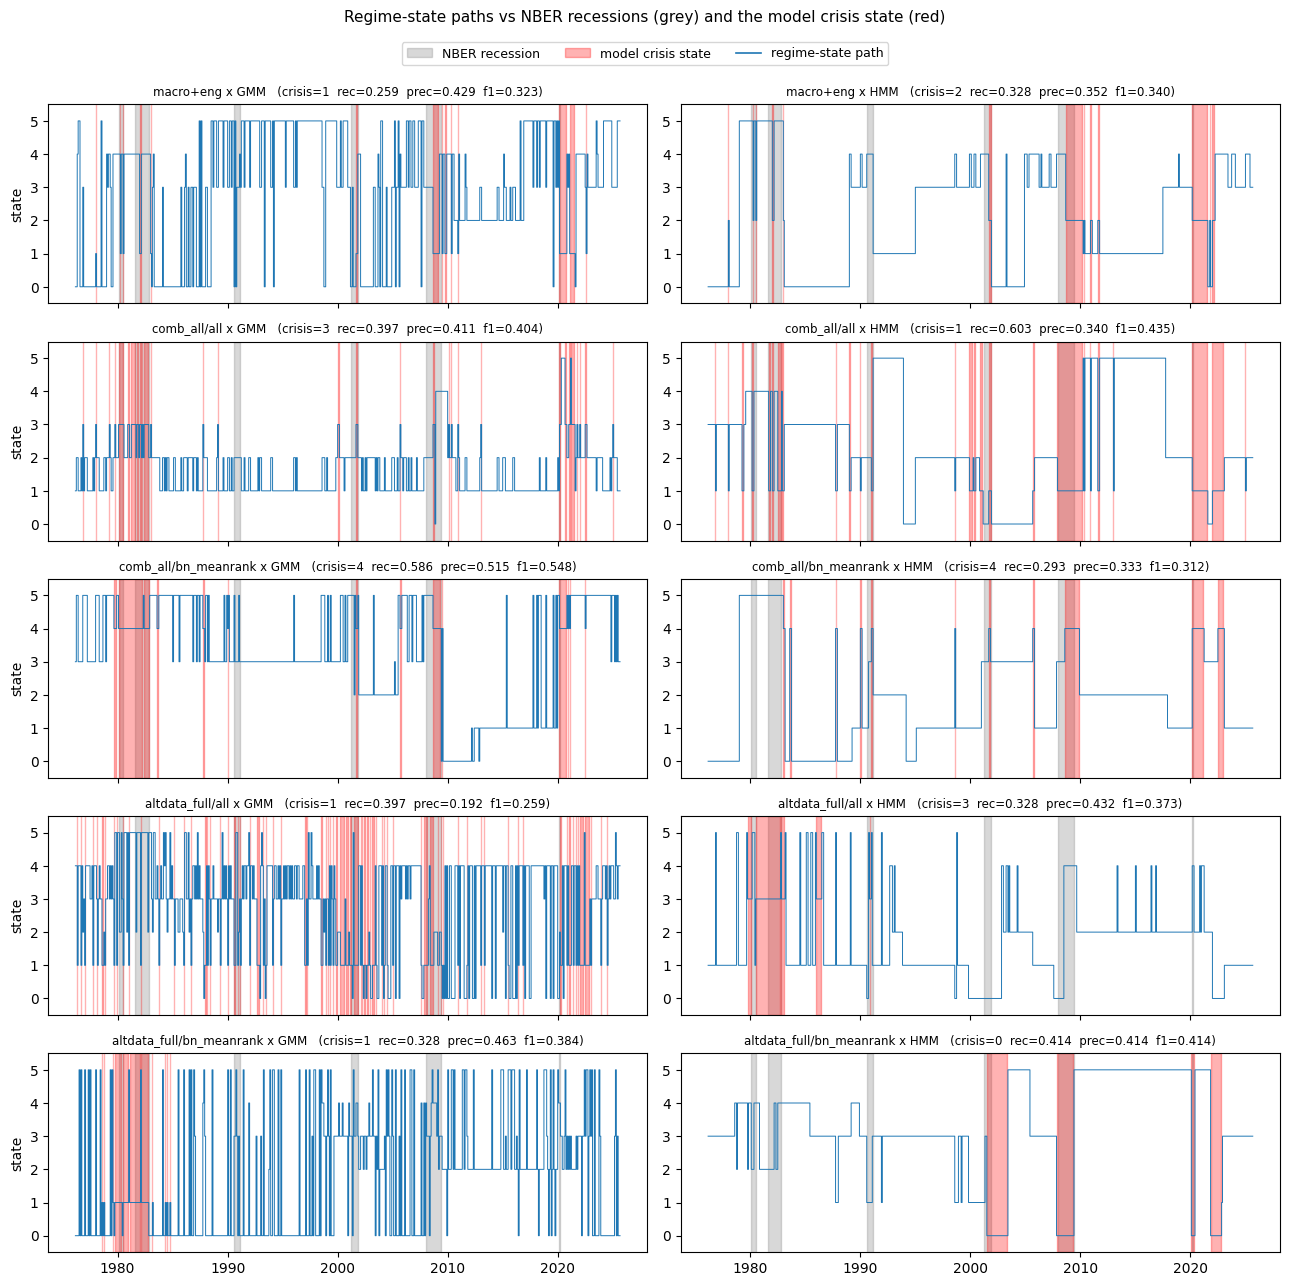

In [8]:
print('=== [4/7] State-path charts (5 configs x GMM/HMM) ===', flush=True)
fig, axes = plt.subplots(len(SPECS), 2, figsize=(13, 12.5), sharex=True)
for i, (name, fb, sel, lab) in enumerate(SPECS):
    sc, feats = SC[name]; idx = sc.index
    ur = (usrec.reindex(idx).fillna(0) > 0).values
    for j, eng in enumerate(('GMM', 'HMM')):
        ax = axes[i, j]
        states, crisis, _ = FITS[(name, eng)]
        ax.plot(idx, states.values, drawstyle='steps-post', lw=0.7, color='C0')
        ax.fill_between(idx, 0, 1, where=ur, transform=ax.get_xaxis_transform(),
                        color='grey', alpha=0.30, step='post')
        cr = (states.values == crisis)
        ax.fill_between(idx, 0, 1, where=cr, transform=ax.get_xaxis_transform(),
                        color='red', alpha=0.30, step='post')
        ax.set_ylim(-0.5, 5.5); ax.set_yticks(range(6))
        flag = (states == crisis).astype(int)
        r = recall(flag, sc.index); p = precision(flag, sc.index); f = f1_score(flag, sc.index)
        ax.set_title(f'{name} x {eng}   (crisis={crisis}  rec={r:.3f}  prec={p:.3f}  f1={f:.3f})',
                     fontsize=8.5)
        if j == 0: ax.set_ylabel('state')
handles = [Patch(color='grey', alpha=0.30, label='NBER recession'),
           Patch(color='red', alpha=0.30, label='model crisis state'),
           Line2D([0], [0], color='C0', lw=1.2, label='regime-state path')]
fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, 1.004))
fig.suptitle('Regime-state paths vs NBER recessions (grey) and the model crisis state (red)',
             y=1.025, fontsize=11)
fig.tight_layout()
fig.savefig(OUT / 'fig_state_paths.png', dpi=130, bbox_inches='tight')
print('saved outputs/fig_state_paths.png'); plt.show()

## 7 · Diagnostics — cluster-stability, silhouette & BIC

For every config × engine:
* **Cluster-stability (seed ARI)** — refit the engine under different random seeds and
  average the Adjusted Rand Index against the seed-0 labeling. Closer to **1** = the
  partition is reproducible (not an artefact of one initialisation).
* **Silhouette** — mean silhouette of the state assignment in PC space (higher = better
  separated; can be near 0 or negative for overlapping regimes).
* **BIC** — Bayesian Information Criterion of the fitted model (lower = better fit per
  parameter); exact for GMM, and computed from the HMM's log-likelihood and parameter count.

Results are **grouped by engine** (all GMM rows, then all HMM rows). The Recall, Precision
& F1 table is reproduced underneath for side-by-side reading.

In [9]:
def stability_ari(sc, engine, n_seed):
    X = sc.values
    if engine == 'GMM':
        ref = GaussianMixture(6, covariance_type='diag', n_init=10, random_state=0,
                              reg_covar=1e-6, max_iter=100).fit(X).predict(X)
        fits = [GaussianMixture(6, covariance_type='diag', n_init=10, random_state=s,
                reg_covar=1e-6, max_iter=100).fit(X).predict(X) for s in range(1, n_seed + 1)]
    else:
        m, lv, A, pi, _ = fit_hmm(X, n_states=6, seed=0); ref = vit(X, m, lv, A, pi)
        fits = []
        for s in range(1, n_seed + 1):
            mm, lvv, AA, pp, _ = fit_hmm(X, n_states=6, seed=s); fits.append(vit(X, mm, lvv, AA, pp))
    aris = [adjusted_rand_score(ref, f) for f in fits]
    return float(np.mean(aris)), float(np.std(aris))

def bic_silhouette(sc, states, engine, extra):
    X = sc.values
    sil = float(silhouette_score(X, states)) if len(set(states)) > 1 else float('nan')
    if engine == 'GMM':
        bic = float(extra.bic(X))
    else:
        m, lv, A, pi, ll = extra; T, dd = X.shape; K = 6
        p = K*dd + K*dd + K*(K-1) + (K-1)        # means + diag vars + transitions + initial
        bic = float(-2*ll + p*np.log(T))
    return sil, bic

print('=== [5/7] Diagnostics - refitting across seeds (longest stage) ===', flush=True)
diag_rows = []
for eng in ('GMM', 'HMM'):                       # engine-major: all GMM rows, then all HMM rows
    for name, fb, sel, lab in SPECS:
        sc, feats = SC[name]
        print(f'  - {eng} / {name} ...', flush=True)
        states, crisis, extra = FITS[(name, eng)]
        sil, bic = bic_silhouette(sc, states.values, eng, extra)
        am, asd = stability_ari(sc, eng, n_seed=(10 if eng == 'GMM' else 5))
        diag_rows.append(dict(engine=eng, config=name, n_feat=len(feats), n_PCs=sc.shape[1],
                              n_states=6, silhouette=round(sil, 3), BIC=round(bic, 1),
                              ari_mean=round(am, 3), ari_std=round(asd, 3)))
        print(f'    {eng}  {name:26s} sil={sil:+.3f}  BIC={bic:10.1f}  ARI={am:.3f} +/- {asd:.3f}',
              flush=True)
diag = pd.DataFrame(diag_rows)
diag.to_csv(OUT / 'table_diagnostics.csv', index=False)
print('\nsaved outputs/table_diagnostics.csv\n')

# grouped table (engine -> config), gradient-shaded on the comparable metrics
disp = diag.set_index(['engine', 'config'])
display(disp.style
        .background_gradient(cmap='Greens', subset=['ari_mean'])
        .background_gradient(cmap='Blues', subset=['silhouette'])
        .format({'silhouette': '{:+.3f}', 'BIC': '{:,.1f}', 'ari_mean': '{:.3f}', 'ari_std': '{:.3f}'}))

# re-show the metrics table for side-by-side reading
print('\nRecall, Precision & F1 table (reproduced):')
kt = pd.read_csv(OUT / 'regime_metrics_table.csv')
display(kt.style.hide(axis='index')
    .background_gradient(cmap='Blues',   subset=['Recall_GMM',    'Recall_HMM'],    vmin=0.0, vmax=1.0)
    .background_gradient(cmap='Purples', subset=['Precision_GMM', 'Precision_HMM'], vmin=0.0, vmax=1.0)
    .background_gradient(cmap='Greens',  subset=['F1_GMM',        'F1_HMM'],        vmin=0.0, vmax=1.0)
    .format({'Recall_GMM': '{:.3f}', 'Recall_HMM': '{:.3f}',
             'Precision_GMM': '{:.3f}', 'Precision_HMM': '{:.3f}',
             'F1_GMM': '{:.3f}', 'F1_HMM': '{:.3f}'}))

=== [5/7] Diagnostics - refitting across seeds (longest stage) ===
  - GMM / macro+eng ...
    GMM  macro+eng                  sil=-0.032  BIC=  112915.5  ARI=0.406 +/- 0.057
  - GMM / comb_all/all ...
    GMM  comb_all/all               sil=+0.032  BIC=  137984.5  ARI=0.343 +/- 0.075
  - GMM / comb_all/bn_meanrank ...
    GMM  comb_all/bn_meanrank       sil=+0.010  BIC=   48612.1  ARI=0.551 +/- 0.176
  - GMM / altdata_full/all ...
    GMM  altdata_full/all           sil=-0.039  BIC=   31646.1  ARI=0.534 +/- 0.104
  - GMM / altdata_full/bn_meanrank ...
    GMM  altdata_full/bn_meanrank   sil=+0.025  BIC=   10872.7  ARI=0.761 +/- 0.103
  - HMM / macro+eng ...
    HMM  macro+eng                  sil=+0.003  BIC=  112087.4  ARI=0.642 +/- 0.118
  - HMM / comb_all/all ...
    HMM  comb_all/all               sil=+0.003  BIC=  137567.4  ARI=0.777 +/- 0.066
  - HMM / comb_all/bn_meanrank ...
    HMM  comb_all/bn_meanrank       sil=+0.065  BIC=   47805.4  ARI=0.623 +/- 0.082
  - HMM / altdata_f


Recall, Precision & F1 table (reproduced):


config,n_feat,n_PCs,n_rec,Recall_GMM,Recall_HMM,Precision_GMM,Precision_HMM,F1_GMM,F1_HMM
macro+eng,141,62,58,0.259,0.328,0.429,0.352,0.323,0.340
comb_all/all,176,76,58,0.397,0.603,0.411,0.340,0.404,0.435
comb_all/bn_meanrank,76,28,58,0.586,0.293,0.515,0.333,0.548,0.312
altdata_full/all,35,19,58,0.397,0.328,0.192,0.432,0.259,0.373
altdata_full/bn_meanrank,9,7,58,0.328,0.414,0.463,0.414,0.384,0.414


## 8 · The final model — HMM of `altdata_full/bn_meanrank`

We select this as the final model on the basis of **joint Recall and Precision**: among the
alt-data configurations it achieves the **most balanced Recall / Precision (0.414 / 0.414)
with the fewest features** — a compact, alt-data-only 9-feature set sized by the Bai & Ng
screen. Its F1 of 0.414 reflects that equal Recall and Precision, meaning the model is not
systematically biased toward over- or under-calling crises. Configs that reach higher F1
(e.g., `comb_all/bn_meanrank` GMM at F1 = 0.548) do so with 76 features across combined
macro + alt-data bundles; within the alt-data-only space this model is the best balanced
choice. The rest of the notebook re-derives it end-to-end and characterises it.

In [10]:
print('=== [6/7] Final model - fit HMM of altdata_full/bn_meanrank ===', flush=True)
# re-derive the final model end-to-end (deterministic -> reproduces the table row)
FEATS = bn_select(fb_alt, fb_macro)
scores_f, feats_f, pca_f = subset_pca(fb_alt, FEATS)
Xf = scores_f.values
mF, lvF, AF, piF, llF = fit_hmm(Xf, n_states=6, seed=0)
if not np.isfinite(llF): mF, lvF, AF, piF, llF = fit_hmm(Xf, n_states=6, seed=0)
statesF = pd.Series(vit(Xf, mF, lvF, AF, piF), index=scores_f.index, name='state')
crisisF = ownership_crisis(statesF.values, Xf)
postF = filt(Xf, mF, lvF, AF, piF)               # filtered posteriors, T x 6
NPC = scores_f.shape[1]
flagF = (statesF == crisisF).astype(int)
rF = recall(flagF, scores_f.index)
pF = precision(flagF, scores_f.index)
fF = f1_score(flagF, scores_f.index)
print(f'final model: {len(feats_f)} features -> {NPC} PCs -> 6-state HMM', flush=True)
print(f'selected features: {feats_f}')
print(f'crisis state = {crisisF}   |   Recall = {rF:.3f}   |   Precision = {pF:.3f}   |   F1 = {fF:.3f}')
assert len(feats_f) == 9 and NPC == 7, (len(feats_f), NPC)

=== [6/7] Final model - fit HMM of altdata_full/bn_meanrank ===
final model: 9 features -> 7 PCs -> 6-state HMM
selected features: ['FF_RF', 'IR_dtb3', 'IR_dtb6', 'IR_dgs1', 'FF_Mkt_RF', 'IR_dgs2', 'BAB_USA', 'FF_RMW', 'BLM_SPGSCI']
crisis state = 0   |   Recall = 0.414   |   Precision = 0.414   |   F1 = 0.414


### 8a · Feature distribution by HMM state

All nine input features, summarised within each HMM state, in three views:
* **standardized (z)** — shown as a heatmap (z-score over the whole sample), so the values are
  comparable across features: red = the feature runs high in that state, blue = low;
* **raw transformed units** — the stationarity-adjusted series the model actually uses
  (rate features are monthly *changes*; factor / commodity features are returns);
* **raw (untransformed) units** — the original series before transformation (rate features are
  *levels* in %; factors / commodities are monthly returns).

Each table carries a `description` column explaining what every feature is. The full long
table (all three means per state × feature) is saved to `final_feature_by_state.csv`.

=== [7/7] Final model - profiles, loadings, transition & probabilities ===
saved outputs/final_feature_by_state.csv   (crisis state = 0 )

Per-state size:


state,0,1,2,3,4,5
n_months,58.0,34.0,23.0,243.0,68.0,169.0
pct,9.7,5.7,3.9,40.8,11.4,28.4
is_crisis,1.0,0.0,0.0,0.0,0.0,0.0



Feature mean by state - standardized (z):  [heatmap]


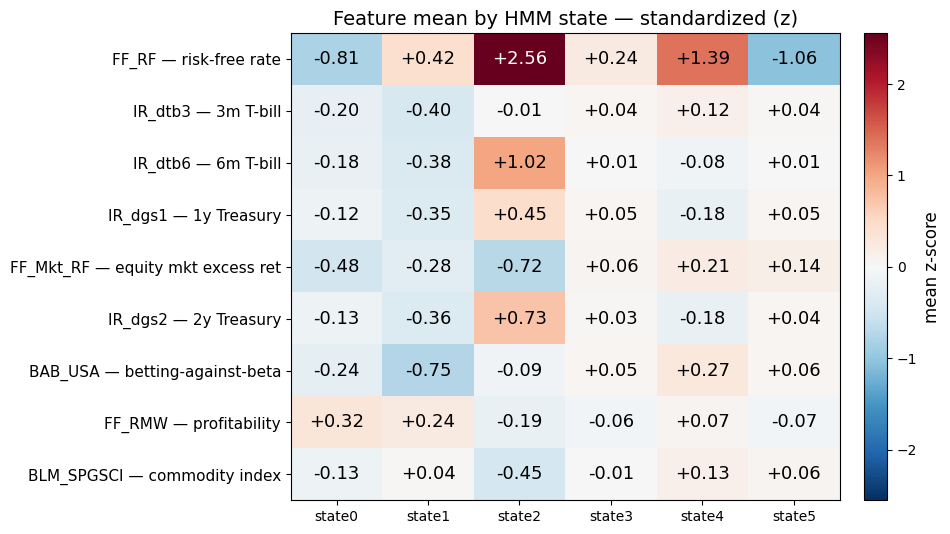

Feature mean by state - raw transformed units:


,state0,state1,state2,state3,state4,state5,description
FF_RF,0.001,0.005,0.011,0.004,0.007,0.000,Risk-free rate — 1-month US T-bill (Fama-French)
IR_dtb3,-0.061,-0.127,0.003,0.020,0.046,0.019,3-month US Treasury bill rate
IR_dtb6,-0.052,-0.123,0.384,0.018,-0.016,0.018,6-month US Treasury bill rate
IR_dgs1,-0.051,-0.148,0.185,0.022,-0.075,0.019,1-year US Treasury yield
FF_Mkt_RF,-0.014,-0.005,-0.025,0.010,0.016,0.013,"Equity market excess return (Mkt-RF, Fama-French)"
IR_dgs2,-0.053,-0.147,0.297,0.013,-0.076,0.018,2-year US Treasury yield
BAB_USA,0.000,-0.017,0.005,0.010,0.018,0.010,Betting-Against-Beta factor (US)
FF_RMW,0.011,0.009,-0.001,0.002,0.005,0.002,Profitability factor — Robust-minus-Weak (Fama...
BLM_SPGSCI,-0.534,0.405,-2.369,0.111,0.942,0.551,S&P GSCI broad commodity index return



Feature mean by state - raw (untransformed) units:


,state0,state1,state2,state3,state4,state5,description
FF_RF,0.001,0.005,0.011,0.004,0.007,0.000,Risk-free rate — 1-month US T-bill (Fama-French)
IR_dtb3,1.390,5.456,13.128,5.126,9.102,0.645,3-month US Treasury bill rate
IR_dtb6,1.549,5.551,13.107,5.243,9.256,0.729,6-month US Treasury bill rate
IR_dgs1,1.775,5.823,14.157,5.638,10.084,0.852,1-year US Treasury yield
FF_Mkt_RF,-0.014,-0.005,-0.025,0.010,0.016,0.013,"Equity market excess return (Mkt-RF, Fama-French)"
IR_dgs2,2.098,6.028,13.918,5.919,10.376,1.092,2-year US Treasury yield
BAB_USA,0.000,-0.017,0.005,0.010,0.018,0.010,Betting-Against-Beta factor (US)
FF_RMW,0.011,0.009,-0.001,0.002,0.005,0.002,Profitability factor — Robust-minus-Weak (Fama...
BLM_SPGSCI,-0.534,0.405,-2.369,0.111,0.942,0.551,S&P GSCI broad commodity index return


In [11]:
print('=== [7/7] Final model - profiles, loadings, transition & probabilities ===', flush=True)
Xfeat = fb_alt.transformed.loc[scores_f.index, feats_f].astype(float)   # transformed (model) units
Xraw  = alt_all[feats_f].reindex(scores_f.index).astype(float)          # raw, untransformed units
sd = Xfeat.std(ddof=0).replace(0, 1.0); Zfeat = (Xfeat - Xfeat.mean()) / sd
st = statesF
counts = pd.DataFrame({'n_months': st.value_counts().sort_index(),
                       'pct': (100 * st.value_counts(normalize=True).sort_index()).round(1),
                       'is_crisis': [int(s == crisisF) for s in sorted(st.unique())]}).T
def _by_state(df):
    t = df.groupby(st).mean().T; t.columns = [f'state{c}' for c in t.columns]; return t
mean_z, mean_tr, mean_un = _by_state(Zfeat), _by_state(Xfeat), _by_state(Xraw)
desc = pd.Series({c: FEATURE_DESC.get(c, '') for c in feats_f}, name='description')

long_rows = []
for s in sorted(st.unique()):
    msk = (st == s)
    for c in feats_f:
        long_rows.append(dict(state=int(s), is_crisis=int(s == crisisF), feature=c,
                              description=FEATURE_DESC.get(c, ''), n_months=int(msk.sum()),
                              mean_z=round(float(Zfeat.loc[msk, c].mean()), 3),
                              mean_transformed=round(float(Xfeat.loc[msk, c].mean()), 4),
                              mean_untransformed=round(float(Xraw.loc[msk, c].mean()), 4)))
pd.DataFrame(long_rows).to_csv(OUT / 'final_feature_by_state.csv', index=False)
print('saved outputs/final_feature_by_state.csv   (crisis state =', crisisF, ')\n')
print('Per-state size:'); display(counts)

print('\nFeature mean by state - standardized (z):  [heatmap]')
ylab = [f'{c} — {FEATURE_SHORT.get(c, c)}' for c in mean_z.index]
heatmap(mean_z, 'Feature mean by HMM state — standardized (z)', 'fig_feature_by_state_z.png',
        ylabels=ylab, cbar_label='mean z-score')

print('Feature mean by state - raw transformed units:')
display(mean_tr.round(3).join(desc))
print('\nFeature mean by state - raw (untransformed) units:')
display(mean_un.round(3).join(desc))

### 8b · PC factor loadings

The 9 standardized features reduce to **7 principal components**. The loadings heatmap below
shows how each feature contributes to each PC (red = positive, blue = negative; the printout
lists each PC's top-3 features by absolute loading); `explained_var_ratio` is each PC's share
of variance. Saved to `final_pc_loadings.csv`. Intuitive labels follow in the next cell.

saved outputs/final_pc_loadings.csv

PC1  (EVR 37.3%, cum 37.3%):  IR_dgs1 +0.52, IR_dtb6 +0.52, IR_dgs2 +0.50
PC2  (EVR 17.3%, cum 54.7%):  FF_RMW +0.60, FF_Mkt_RF -0.54, BAB_USA +0.50
PC3  (EVR 12.9%, cum 67.6%):  BLM_SPGSCI +0.67, BAB_USA +0.53, FF_Mkt_RF +0.37
PC4  (EVR 11.0%, cum 78.6%):  FF_RF +0.96, BLM_SPGSCI +0.21, BAB_USA +0.09
PC5  (EVR  7.8%, cum 86.4%):  FF_Mkt_RF +0.70, BLM_SPGSCI -0.53, FF_RMW +0.39
PC6  (EVR  6.7%, cum 93.1%):  BAB_USA +0.67, FF_RMW -0.64, BLM_SPGSCI -0.36
PC7  (EVR  5.0%, cum 98.1%):  IR_dtb3 +0.75, IR_dgs2 -0.52, IR_dgs1 -0.27



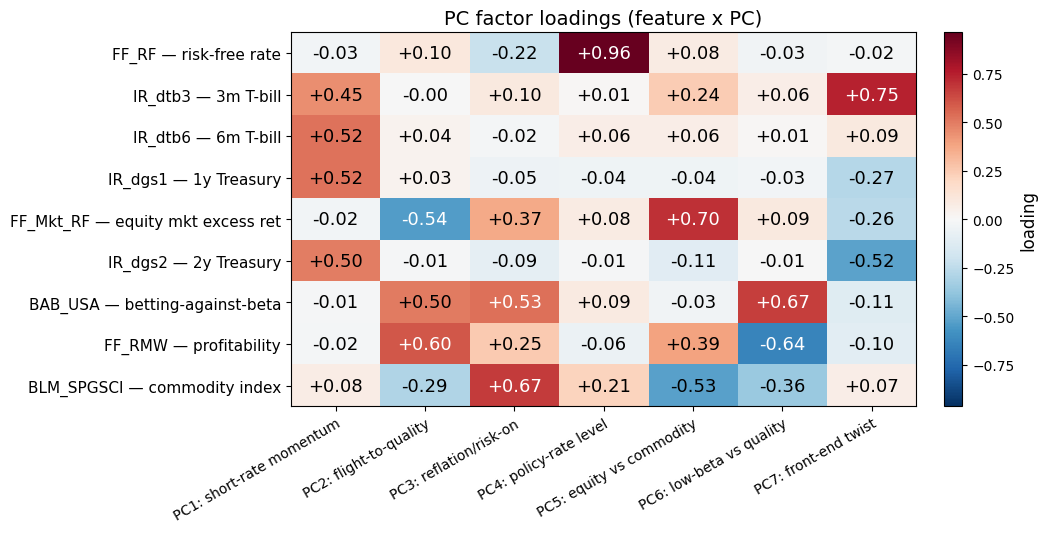

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
explained_var_ratio,0.3732,0.1734,0.1293,0.1101,0.0783,0.0667,0.0496


In [12]:
load = pd.DataFrame(pca_f.components_.T, index=feats_f,
                    columns=[f'PC{i+1}' for i in range(NPC)])
evr = pd.Series(pca_f.explained_variance_ratio_, index=load.columns, name='explained_var_ratio')
out_load = load.round(4).copy()
out_load.loc['__explained_var_ratio__'] = evr.round(4)
out_load.loc['__cum_var_ratio__'] = evr.cumsum().round(4)
out_load.to_csv(OUT / 'final_pc_loadings.csv')
print('saved outputs/final_pc_loadings.csv\n')
for pc in load.columns:
    s = load[pc].reindex(load[pc].abs().sort_values(ascending=False).index)
    top = ', '.join(f'{f} {v:+.2f}' for f, v in s.head(3).items())
    print(f'{pc}  (EVR {evr[pc]*100:4.1f}%, cum {evr.cumsum()[pc]*100:4.1f}%):  {top}')
print()
ylab = [f'{c} — {FEATURE_SHORT.get(c, c)}' for c in load.index]
xlab = [f'{c}: {PC_SHORT.get(c, "")}' for c in load.columns]
heatmap(load, 'PC factor loadings (feature x PC)', 'fig_pc_loadings.png',
        ylabels=ylab, xlabels=xlab, xrot=30, cbar_label='loading')
display(evr.to_frame().T.round(4))

**PC factor labels & interpretation.** Each PC is named from the features that load most
heavily on it. The nine inputs are: monthly *changes* in the 3m / 6m / 1y / 2y Treasury yields
(`IR_dtb3`, `IR_dtb6`, `IR_dgs1`, `IR_dgs2`), the risk-free-rate *level* (`FF_RF`), the equity
market excess return (`FF_Mkt_RF`), the profitability factor (`FF_RMW`), the betting-against-beta
factor (`BAB_USA`), and the S&P GSCI commodity return (`BLM_SPGSCI`).

| PC | var | intuitive label | what a *high* value means |
|---|---|---|---|
| **PC1** | 37% | **Short-rate momentum (policy thrust)** | the front end (3m–2y yields) is *rising together* — monetary tightening; low = easing |
| **PC2** | 17% | **Flight-to-quality rotation** | quality (RMW) and low-beta (BAB) beat the market and commodities — risk-off |
| **PC3** | 13% | **Reflation / pro-cyclical risk premium** | commodities, low-beta and the market all rallying — broad risk-on |
| **PC4** | 11% | **Policy-rate level (rate regime)** | the policy / risk-free rate itself is high (vs ZIRP when low) |
| **PC5** | 8% | **Equities-vs-commodities divergence** | equities lead while commodities lag |
| **PC6** | 7% | **Low-beta vs profitability style spread** | low-beta (BAB) favoured over quality (RMW) — a within-defensive rotation |
| **PC7** | 5% | **Front-end curve twist** | the 3m bill rises relative to the 2y — a twist at the very short end |

PC1 (curve-wide rate *momentum*) and PC4 (the rate *level*) dominate — together ~48% of the
variance — so this alt-data regime space is first and foremost an **interest-rate** space, with
the factor-rotation and commodity signals (PC2/PC3/PC5/PC6) describing the risk environment.

### 8c · PC distribution by HMM state

The mean of each of the 7 PC scores within each HMM state — the compact fingerprint that
distinguishes the regimes (shown as a heatmap; red = high, blue = low). Saved to
`final_pc_by_state.csv`.

saved outputs/final_pc_by_state.csv   (crisis state = 0 )



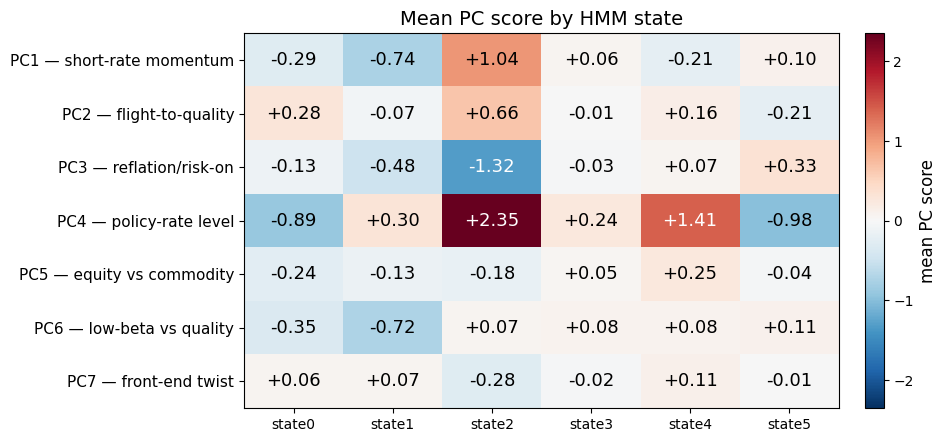

In [13]:
pc_mean = scores_f.groupby(statesF).mean().T
pc_mean.columns = [f'state{c}' for c in pc_mean.columns]
pc_mean.to_csv(OUT / 'final_pc_by_state.csv')
print('saved outputs/final_pc_by_state.csv   (crisis state =', crisisF, ')\n')
ylab = [f'{c} — {PC_SHORT.get(c, "")}' for c in pc_mean.index]
heatmap(pc_mean, 'Mean PC score by HMM state', 'fig_pc_by_state.png',
        ylabels=ylab, cbar_label='mean PC score')

### 8d · State labels & interpretation

The table below supports the labelling: each state's size, whether it is the crisis state,
and what share of its months overlap an NBER recession.

In [14]:
ur = (usrec.reindex(scores_f.index) > 0)
support = pd.DataFrame({
    'n_months': st.value_counts().sort_index(),
    'pct': (100 * st.value_counts(normalize=True).sort_index()).round(1),
    'is_crisis': [int(s == crisisF) for s in sorted(st.unique())],
    'nber_overlap_pct': [round(100 * float(ur[st == s].mean()), 1) for s in sorted(st.unique())],
})
display(support)

,n_months,pct,is_crisis,nber_overlap_pct
state,,,,
0,58,9.7,1,41.4
1,34,5.7,0,20.6
2,23,3.9,0,52.2
3,243,40.8,0,1.6
4,68,11.4,0,14.7
5,169,28.4,0,0.6


**State labels & interpretation.** Read from the per-state feature / PC profiles, the NBER
overlap, and when each state occurs. **State 0 is the model's crisis state.**

| state | size | NBER overlap | intuitive label | character |
|---|---|---|---|---|
| **0** | 58 (10%) | **41% (crisis)** | **Acute crisis / risk-off** | the weakest equity returns of any state, policy rate low and falling, quality outperforms — the 2008 and 2020 episodes. This is the crisis flag Recall, Precision & F1 score against. |
| **1** | 34 (6%) | 21% | **Disinflationary easing / soft patch** | front-end rates falling, high-beta leading low-beta, mildly soft equities — mostly 1990s–2000s slowdowns |
| **2** | 23 (4%) | **52%** | **High-inflation tightening (Volcker era)** | extreme rate *level* with the front end still rising and weak equities — almost entirely the early 1980s |
| **3** | 243 (41%) | 2% | **Calm expansion (baseline)** | every factor near its average; the dominant trend-growth regime, present in all decades |
| **4** | 68 (11%) | 15% | **High-rate expansion (1970s–80s)** | elevated but stable policy rates with positive equity returns — concentrated in the 1970s–80s |
| **5** | 169 (28%) | 1% | **Low-rate / post-GFC expansion (ZIRP)** | very low policy rate, steady positive equities — dominated by the 2010s |

The recession signal is split across states 0, 2, 4 and 1; the crisis state alone owns ~41%
of all recession months. Flagging only state 0 as "crisis" is what gives the HMM its Recall /
Precision / F1 here — it cleanly captures the acute 2008 / 2020 drawdowns, while the slower
inflation-era recessions fall into the high-rate states (2 and 4).

### 8e · Regime transition matrix

Row $i$, column $j$ is $P(\text{state }j \text{ next month} \mid \text{state }i \text{ now})$
under the fitted HMM; rows sum to 1. Large diagonal entries mean regimes are persistent.
Saved to `final_transition_matrix.csv`.

saved outputs/final_transition_matrix.csv   (rows sum to 1)



,to_state0,to_state1,to_state2,to_state3,to_state4,to_state5
from_state0,0.908,0.017,0.000,0.000,0.000,0.075
from_state1,0.017,0.798,0.000,0.185,0.000,0.000
from_state2,0.000,0.000,0.617,0.000,0.383,0.000
from_state3,0.006,0.028,0.000,0.958,0.009,0.000
from_state4,0.000,0.000,0.100,0.028,0.871,0.000
from_state5,0.021,0.000,0.000,0.006,0.000,0.973


saved outputs/fig_transition_matrix.png


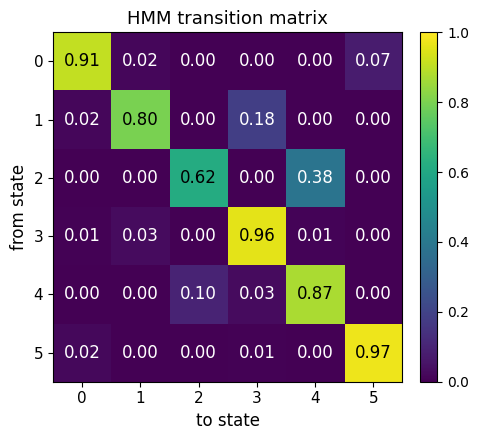

In [15]:
A_df = pd.DataFrame(AF, index=[f'from_state{i}' for i in range(6)],
                    columns=[f'to_state{j}' for j in range(6)])
A_df.to_csv(OUT / 'final_transition_matrix.csv')
print('saved outputs/final_transition_matrix.csv   (rows sum to 1)\n')
display(A_df.round(3))
fig, ax = plt.subplots(figsize=(5.2, 4.5))
im = ax.imshow(AF, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(6)); ax.set_yticks(range(6)); ax.tick_params(labelsize=11)
ax.set_xlabel('to state', fontsize=12); ax.set_ylabel('from state', fontsize=12)
ax.set_title('HMM transition matrix', fontsize=13)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f'{AF[i, j]:.2f}', ha='center', va='center',
                color='white' if AF[i, j] < 0.6 else 'black', fontsize=12)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.ax.tick_params(labelsize=10)
fig.tight_layout()
fig.savefig(OUT / 'fig_transition_matrix.png', dpi=130, bbox_inches='tight')
print('saved outputs/fig_transition_matrix.png'); plt.show()

### 8f · Per-month state probabilities

The final export: for every month, the Viterbi-decoded **`state`** (the exact series the
Recall, Precision & F1 metrics are computed from) plus **`p_state0..p_state5`**, the
HMM's filtered (forward) posterior probabilities of each state — the same fitted model and
decoding family used throughout. (Because Viterbi optimises the joint path while the
posterior is a per-month marginal, the posterior's argmax can differ from `state` in a few
months.) Saved to `final_state_probabilities.csv`.

In [16]:
prob = pd.DataFrame(postF, index=scores_f.index, columns=[f'p_state{k}' for k in range(6)])
prob.insert(0, 'state', statesF.values)
prob.index.name = 'date'; prob = prob.reset_index()
prob['date'] = pd.to_datetime(prob['date']).dt.date
prob.to_csv(OUT / 'final_state_probabilities.csv', index=False)
psum = postF.sum(1)
print('saved outputs/final_state_probabilities.csv')
print(f'rows={len(prob)}   prob-row-sum in [{psum.min():.4f}, {psum.max():.4f}]')
print(f'columns: {list(prob.columns)}\n')
display(prob.head(8)); display(prob.tail(4))

saved outputs/final_state_probabilities.csv
rows=595   prob-row-sum in [1.0000, 1.0000]
columns: ['date', 'state', 'p_state0', 'p_state1', 'p_state2', 'p_state3', 'p_state4', 'p_state5']



,date,state,p_state0,p_state1,p_state2,p_state3,p_state4,p_state5
0,1976-03-01,3,8.195501e-108,7.098298e-48,1.218636e-159,1.000000,6.433623e-75,3.369462e-82
1,1976-04-01,3,2.863831e-05,7.021334e-04,3.519043e-18,0.999111,1.580976e-04,1.651221e-24
2,1976-05-01,3,3.353178e-03,2.316316e-02,2.746823e-07,0.952949,2.053427e-02,1.384128e-13
3,1976-06-01,3,9.561694e-05,2.101262e-03,3.065984e-08,0.997507,2.959396e-04,5.733792e-08
4,1976-07-01,3,3.668478e-04,6.311255e-03,2.579788e-08,0.993205,1.168622e-04,8.109513e-10
5,1976-08-01,3,3.762905e-05,5.545597e-04,4.130208e-10,0.999330,7.823360e-05,2.098643e-08
6,1976-09-01,3,2.717600e-04,3.498735e-03,1.381847e-09,0.996170,5.973852e-05,1.908502e-08
7,1976-10-01,3,8.803165e-05,9.767989e-04,3.725814e-10,0.998854,8.103770e-05,4.249175e-09


,date,state,p_state0,p_state1,p_state2,p_state3,p_state4,p_state5
591,2025-06-01,3,0.000866,0.015493,7.733073e-12,0.983612,0.000026,3.558481e-06
592,2025-07-01,3,0.000066,0.000557,7.237433e-12,0.999352,0.000023,2.382458e-06
593,2025-08-01,3,0.000017,0.000196,1.649297e-11,0.999745,0.000042,6.197158e-08
594,2025-09-01,3,0.000174,0.001215,7.305805e-12,0.998594,0.000016,1.439927e-07


## 9 · Notes & caveats

* **Arbitrary state ids.** State numbers are interchangeable labels; read them via the
  recession overlap, the crisis-state flag, and the per-state PC/feature profiles, not by
  their index.
* **HMM stability.** The HMM is the more fragile engine (see the ARI column); the crisis
  state is pinned by Mahalanobis ownership precisely because raw HMM states can be unstable.
* **Reproducibility.** Thread pinning + full-SVD PCA + fixed seeds make every number above
  byte-reproducible across runs.